# Load Dataset

In [1]:
# data
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore") 

# visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# model
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from scipy.cluster.hierarchy import dendrogram, ward
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import AffinityPropagation
from sklearn.cluster import MeanShift, estimate_bandwidth

# grid search
from sklearn.model_selection import GridSearchCV

# evaluation
from sklearn.metrics.cluster import silhouette_score
from sklearn.model_selection import cross_val_score
from sklearn import metrics
from sklearn.metrics import *

In [2]:
df = pd.read_csv('data/정제데이터/구별데이터_스케일링.csv', encoding='cp949')

# 환경불평등지수
- 기초수급자_인구밀도 + (1-인당녹지면적)

In [3]:
df['환경불평등지수'] = df.기초수급자_인구밀도 + (1- df.인당녹지면적)

In [4]:
df.head(3)

,시군구,기초수급자_인구밀도,저소득층_비율,총생활인구,초미세먼지,미세먼지,인당녹지면적,총공시지가평균,평균기온(°C),도시재생사업수,환경불평등지수
0,강남구,0.258356,0.891770,1.000000,0.50,0.285714,0.827140,1.000000,0.606061,0.0,0.431216
1,강동구,0.518524,0.461778,0.601108,0.75,0.571429,0.715354,0.259889,0.525253,0.4,0.803171
2,강북구,1.000000,0.241271,0.141629,0.25,0.571429,0.501950,0.066923,0.565657,0.6,1.498050


In [5]:
data = df[['총공시지가평균','환경불평등지수']]

# Modeling

## from sklearn.cluster import AgglomerativeClustering 
hc = AgglomerativeClustering(n_clusters = 5, affinity = 'euclidean', linkage ='ward')Hierarchical agglomerative clustering

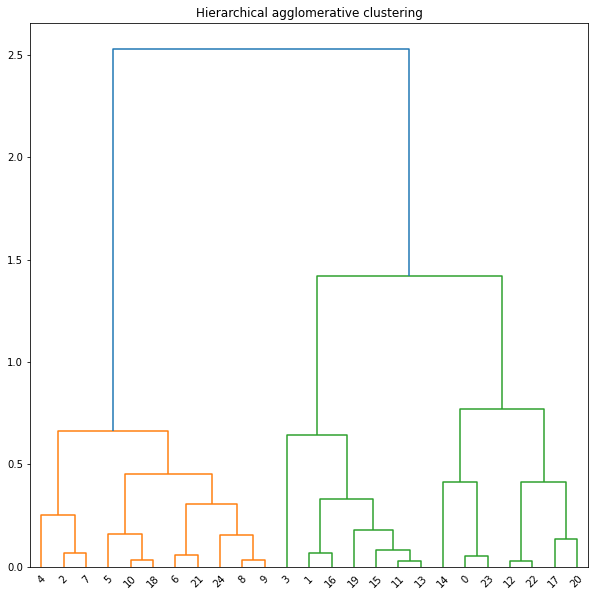

In [8]:
import scipy.cluster.hierarchy as shc

plt.figure(figsize=(10, 10))
plt.title("Hierarchical agglomerative clustering")
dend = shc.dendrogram(shc.linkage(data, method='ward'))

In [9]:
from sklearn.cluster import AgglomerativeClustering 
k=3
hc = AgglomerativeClustering(n_clusters = k, affinity = 'euclidean', linkage ='ward')
# 클러스터링 결과 각 데이터가 몇 번째 그룹에 속하는지 저장
df['cluster'] = hc.fit_predict(data)

Gulim


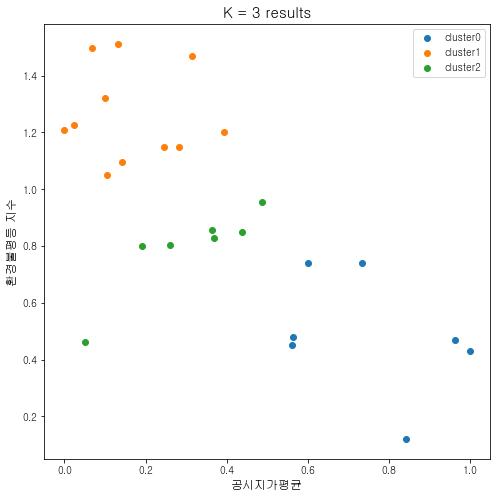

In [10]:
import matplotlib.pyplot as plt

# 한글폰트설정
font_name = 'Gulim'
print(font_name)
plt.rc('font', family=font_name)

plt.figure(figsize = (8, 8))

for i in range(k):
    plt.scatter(df.loc[df['cluster'] == i, '총공시지가평균'], df.loc[df['cluster'] == i, '환경불평등지수'], label = 'cluster' + str(i))

plt.legend()
plt.title('K = %d results'%k , size = 15)
plt.xlabel('공시지가평균', size = 12)
plt.ylabel('환경불평등 지수', size = 12)
plt.show()

In [11]:
cluster_cnt = df.groupby('cluster').agg({'시군구':'count'}).reset_index()
cluster_des = df.groupby('cluster').mean().reset_index()

In [12]:
a = pd.merge(cluster_cnt,cluster_des)

In [13]:
import dataframe_image as dfi

dfi.export(a, './image/10-3구별_GMM_describe.png', max_cols = -1, max_rows = -1)

In [22]:
df[df.cluster==1].시군구.unique()

array(['강북구', '관악구', '광진구', '구로구', '금천구', '노원구', '도봉구', '동대문구', '양천구',
       '은평구', '중랑구'], dtype=object)

In [21]:
df[df.cluster==0].시군구.unique()

array(['강남구', '마포구', '서초구', '송파구', '용산구', '종로구', '중구'], dtype=object)

In [23]:
df

,시군구,기초수급자_인구밀도,저소득층_비율,총생활인구,초미세먼지,미세먼지,인당녹지면적,총공시지가평균,평균기온(°C),도시재생사업수,환경불평등지수,cluster
0,강남구,0.258356,0.891770,1.000000,0.50,0.285714,0.827140,1.000000,0.606061,0.0,0.431216,0
1,강동구,0.518524,0.461778,0.601108,0.75,0.571429,0.715354,0.259889,0.525253,0.4,0.803171,2
2,강북구,1.000000,0.241271,0.141629,0.25,0.571429,0.501950,0.066923,0.565657,0.6,1.498050,1
3,강서구,0.460660,1.000000,0.906604,1.00,0.857143,1.000000,0.050196,0.464646,0.1,0.460660,2
4,관악구,0.806628,0.276906,0.116055,0.25,0.142857,0.337779,0.314431,0.252525,0.2,1.468850,1
5,광진구,0.573806,0.316486,0.266399,0.50,0.285714,0.371599,0.392770,0.585859,0.1,1.202206,1
6,구로구,0.553183,0.413605,0.458227,0.50,0.714286,0.503193,0.104274,0.585859,0.4,1.049989,1
7,금천구,0.512857,0.170871,0.149014,1.00,0.428571,0.000000,0.131990,0.676768,0.3,1.512857,1
8,노원구,0.784855,0.477565,0.433462,0.75,0.428571,0.557502,0.023756,0.141414,0.2,1.227353,1
9,도봉구,0.788059,0.195392,0.000000,0.25,0.285714,0.579902,0.000000,0.343434,0.4,1.208156,1
